In [1]:
from typing import Callable

import numpy as np
import numpy.typing as npt

as_numpy: Callable[[npt.NDArray], npt.NDArray]

try:
    import cupy as cp
    import cupyx

    if cp.cuda.runtime.getDeviceCount() > 0:
        xp = cp
        scatter_add = cupyx.scatter_add
        as_numpy = cp.asnumpy
        device = "cuda"
    else:
        raise Exception("CUDA is not available")
except (ImportError, Exception):
    xp = np
    scatter_add = np.add.at
    as_numpy = lambda x: x
    device = "cpu"

device

'cuda'

In [2]:
class Parameter:
    def __init__(self, data: npt.NDArray):
        self.data = data
        self.grad = xp.zeros_like(data)

In [3]:
from typing import Generator


class Module:
    @property
    def parameters(self) -> Generator[Parameter, None, None]:
        for _, parameter in self.named_parameters():
            yield parameter

    def named_parameters(
        self, prefix=""
    ) -> Generator[tuple[str, Parameter], None, None]:
        for name, value in self.__dict__.items():
            if value is None:
                continue

            full_name = f"{prefix}.{name}" if prefix else name

            if isinstance(value, Parameter):
                yield full_name, value
            elif isinstance(value, Module):
                yield from value.named_parameters(full_name)
            elif isinstance(value, (list, tuple)):
                for i, item in enumerate(value):
                    if isinstance(item, Module):
                        item_name = f"{full_name}.{i}"

                        yield from item.named_parameters(item_name)

    def trainable_parameters(self):
        return sum(parameter.data.size for parameter in self.parameters)

    def state_dict(self) -> dict[str, npt.NDArray]:
        state = {}

        for name, parameter in self.named_parameters():
            state[name] = xp.copy(parameter.data)

        return state

    def load_state_dict(self, state_dict: dict[str, npt.NDArray]):
        model_parameters = dict(self.named_parameters())

        missing_keys = [name for name in model_parameters if name not in state_dict]

        unexpected_keys = [name for name in state_dict if name not in model_parameters]

        if missing_keys or unexpected_keys:
            raise ValueError(
                "State dict mismatch:\n"
                f"Missing keys: {missing_keys}\n"
                f"Unexpected keys: {unexpected_keys}"
            )

        for name, parameter in model_parameters.items():
            value = state_dict[name]

            if parameter.data.shape != value.shape:
                raise ValueError(
                    f"Shape mismatch for '{name}': "
                    f"model={parameter.data.shape}, "
                    f"state_dict={value.shape}"
                )

            parameter.data[...] = value

    def zero_grad(self):
        for parameter in self.parameters:
            parameter.grad[...] = 0

In [4]:
class ReLU(Module):
    _inputs: npt.NDArray = None

    def __init__(self):
        pass

    def __call__(self, inputs: npt.NDArray) -> npt.NDArray:
        self._inputs = inputs

        return xp.maximum(0, inputs)

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        return xp.where(self._inputs > 0, grad, 0)

In [5]:
class Softmax(Module):
    _outputs: npt.NDArray = None

    def __init__(self):
        pass

    def __call__(self, inputs: npt.NDArray) -> npt.NDArray:
        max_logit = xp.max(inputs, axis=-1, keepdims=True)

        self._outputs = xp.exp(inputs - max_logit) / xp.sum(
            xp.exp(inputs - max_logit), axis=-1, keepdims=True
        )

        return self._outputs

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        return grad * self._outputs - self._outputs * xp.sum(
            grad * self._outputs, axis=-1, keepdims=True
        )

In [6]:
class PositionalEncoding(Module):
    def __init__(self, embedding_length: int, scale=1.0):
        self._embedding_length = embedding_length
        self._scale = scale

    def __call__(self, inputs: npt.NDArray) -> npt.NDArray:
        T = inputs.shape[1]

        pos = xp.arange(0, T, dtype=int)[:, xp.newaxis]

        denominator = (
            xp.arange(0, self._embedding_length) // 2 * 2
        ) / self._embedding_length
        denominator = 1 / (10_000**denominator)
        denominator = denominator[xp.newaxis, ...]

        inner = pos * denominator
        pe_sin = xp.sin(inner)
        pe_cos = xp.cos(inner)

        pe_sin[:, xp.arange(1, self._embedding_length, 2)] = 0
        pe_cos[:, xp.arange(0, self._embedding_length, 2)] = 0

        positional_encoding = pe_sin + pe_cos

        return inputs + positional_encoding[xp.newaxis, ...] * self._scale

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        return grad

In [7]:
class EmbeddingLayer(Module):
    _inputs: npt.NDArray = None

    def __init__(self, vocab_size: int, embedding_dim: int):
        scale = 1.0 / math.sqrt(embedding_dim)

        self.embeddings = Parameter(xp.random.randn(vocab_size, embedding_dim) * scale)

    def __call__(self, inputs: npt.NDArray) -> npt.NDArray:
        self._inputs = inputs
        return self.embeddings.data[inputs]

    def backward(self, grad: npt.NDArray):
        scatter_add(self.embeddings.grad, self._inputs, grad)

In [8]:
import math


class Linear(Module):
    _inputs: npt.NDArray = None

    def __init__(self, in_features: int, out_features: int, include_bias=True):
        limit = math.sqrt(6 / (in_features))

        self.weights = Parameter(
            xp.random.uniform(-limit, limit, (in_features, out_features))
        )
        self.bias = Parameter(xp.zeros((1, out_features))) if include_bias else None

        self.include_bias = include_bias

    def __call__(self, inputs: npt.NDArray) -> npt.NDArray:
        self._inputs = inputs

        out = xp.matmul(inputs, self.weights.data)

        if self.include_bias:
            out += self.bias.data

        return out

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        inputs_flat = self._inputs.reshape(-1, self._inputs.shape[-1])
        grad_flat = grad.reshape(-1, grad.shape[-1])

        dL_dA = xp.matmul(grad, self.weights.data.T)
        dL_dW = xp.matmul(inputs_flat.T, grad_flat)

        if self.include_bias:
            dL_dB = xp.sum(grad_flat, axis=0, keepdims=True)
            self.bias.grad += dL_dB

        self.weights.grad += dL_dW

        return dL_dA

In [9]:
class FeedForwardNetwork(Module):
    def __init__(self, in_features: int, hidden_features: int, out_features: int):
        self.linear1 = Linear(in_features, hidden_features)
        self.activation = ReLU()
        self.linear2 = Linear(hidden_features, out_features)

    def __call__(self, inputs: npt.NDArray) -> npt.NDArray:
        x = self.linear1(inputs)
        x = self.activation(x)
        x = self.linear2(x)

        return x

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        grad = self.linear2.backward(grad)
        grad = self.activation.backward(grad)
        grad = self.linear1.backward(grad)

        return grad

In [10]:
class LayerNorm(Module):
    _mean: npt.NDArray = None
    _mu: npt.NDArray = None
    _var: npt.NDArray = None
    _std: npt.NDArray = None

    _outputs: npt.NDArray = None

    def __init__(self, in_features: int):
        self._in_features = in_features

        self.gain = Parameter(xp.ones((1, in_features)))
        self.bias = Parameter(xp.zeros((1, in_features)))

    def __call__(self, inputs: npt.NDArray) -> npt.NDArray:
        epsilon = 1e-5

        self._mean = (1 / self._in_features) * xp.sum(inputs, axis=-1, keepdims=True)
        self._mu = inputs - self._mean
        self._var = (1 / self._in_features) * xp.sum(
            xp.square(self._mu), axis=-1, keepdims=True
        )
        self._std = xp.sqrt(self._var + epsilon)
        self._outputs = self.gain.data * (self._mu / self._std) + self.bias.data

        return self._outputs

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        """
        [Reference](https://robotchinwag.com/posts/layer-normalization-deriving-the-gradient-for-the-backward-pass/)
        """
        inv_std = 1 / self._std
        inv_std3 = inv_std**3

        n = self._in_features

        g = grad * self.gain.data

        dL_dX = g * inv_std - xp.sum(
            g[..., xp.newaxis]
            / n
            * (
                inv_std[..., xp.newaxis]
                + self._mu[..., xp.newaxis]
                * self._mu[..., xp.newaxis, :]
                * inv_std3[..., xp.newaxis]
            ),
            axis=-2,
        )

        dL_dGain = xp.sum(grad * self._mu * inv_std, axis=(0, 1))
        dL_dB = xp.sum(grad, axis=(0, 1))

        self.gain.grad += dL_dGain
        self.bias.grad += dL_dB

        return dL_dX

In [11]:
class MultiHeadAttention(Module):
    _queries: npt.NDArray = None
    _keys: npt.NDArray = None
    _values: npt.NDArray = None
    _attention_weights: npt.NDArray = None

    def __init__(self, in_features: int, out_features: int, n_heads: int):
        self._in_features = in_features
        self._out_features = out_features
        self._n_heads = n_heads

        self.query_linear = Linear(in_features, out_features, include_bias=False)
        self.key_linear = Linear(in_features, out_features, include_bias=False)
        self.value_linear = Linear(in_features, out_features, include_bias=False)

        self.softmax = Softmax()

        self.final_projection = Linear(out_features, out_features, include_bias=False)

    def __call__(self, inputs: npt.NDArray, mask: npt.NDArray = None) -> npt.NDArray:
        B, T, I = inputs.shape
        D = self._out_features
        H = self._n_heads
        Dh = D // H

        assert I == self._in_features
        assert D % H == 0

        # [B, T, I] @ [I, D] -> [B, T, D]
        queries = self.query_linear(inputs)
        keys = self.key_linear(inputs)
        values = self.value_linear(inputs)

        # [B, T, H, Dh]
        shape = (B, T, H, Dh)

        # [B, T, D] -> [B, T, H, Dh]
        queries = xp.reshape(queries, shape)
        keys = xp.reshape(keys, shape)
        values = xp.reshape(values, shape)

        # [B, T, H, Dh] -> [B, H, T, Dh]
        queries = xp.transpose(queries, axes=[0, 2, 1, 3])
        keys = xp.transpose(keys, axes=[0, 2, 1, 3])
        values = xp.transpose(values, axes=[0, 2, 1, 3])

        # [B, H, T, Dh] -> [B, H, Dh, T]
        t_keys = xp.transpose(keys, axes=[0, 1, 3, 2])

        # [B, H, T, Dh] @ [B, H, Dh, T] -> [B, H, T, T]
        # S = Q @ K^T
        attention_scores = xp.matmul(queries, t_keys)

        # Divide by sqrt(Dh)
        attention_scores = attention_scores / xp.sqrt(keys.shape[-1])

        if mask is not None:
            attention_scores += mask

        # Softmax
        attention_weights = self.softmax(attention_scores)

        # [B, H, T, T] @ [B, H, T, Dh] -> [B, H, T, Dh]
        # O = A @ V
        final_vector = xp.matmul(attention_weights, values)

        # [B, H, T, Dh] -> [B, T, H, Dh]
        final_vector = xp.transpose(final_vector, axes=[0, 2, 1, 3])

        # [B, T, H, Dh] -> [B, T, D]
        final_vector = xp.reshape(final_vector, [B, T, self._out_features])

        # [B, T, D] @ [D, D] -> [B, T, D]
        final_vector = self.final_projection(final_vector)

        self._queries = queries
        self._keys = keys
        self._values = values
        self._attention_weights = attention_weights

        return final_vector

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        B, T, D = grad.shape
        H = self._n_heads
        Dh = D // H

        assert D == self._out_features
        assert D % H == 0

        grad = self.final_projection.backward(grad)

        # [B, T, H, Dh]
        shape = (B, T, H, Dh)

        # [B, T, D] -> [B, T, H, Dh]
        grad = xp.reshape(grad, shape)

        # [B, T, H, Dh] -> [B, H, T, Dh]
        grad = xp.transpose(grad, axes=[0, 2, 1, 3])

        # [B, H, T, T] -> [B, H, T, T]
        t_attention_weights = xp.transpose(self._attention_weights, axes=[0, 1, 3, 2])

        # [B, H, T, T] @ [B, H, T, Dh] -> [B, H, T, Dh]
        # dL/dV = A^T @ dL/dO
        dL_dValues = xp.matmul(t_attention_weights, grad)

        # [B, H, T, Dh] -> [B, H, Dh, T]
        t_values = xp.transpose(self._values, axes=[0, 1, 3, 2])

        # [B, H, T, Dh] @ [B, H, Dh, T] -> [B, H, T, T]
        # dL/dA = dL/dO @ V^T
        dL_dAttention_Weights = xp.matmul(grad, t_values)

        # dL/dS = softmax_backward(dL/dA) / sqrt(Dh)
        dL_dAttention_Scores = self.softmax.backward(dL_dAttention_Weights) / xp.sqrt(
            self._keys.shape[-1]
        )

        # [B, H, T, T] -> [B, H, T, T]
        t_dL_dAttention_Scores = xp.transpose(dL_dAttention_Scores, axes=[0, 1, 3, 2])

        # [B, H, T, T] @ [B, H, T, Dh] -> [B, H, T, Dh]
        # dL/dK = dL/dS^T @ Q
        dL_dKeys = xp.matmul(t_dL_dAttention_Scores, self._queries)

        # [B, H, T, T] @ [B, H, T, Dh] -> [B, H, T, Dh]
        # dL/dQ = dL/dS @ K
        dL_dQueries = xp.matmul(dL_dAttention_Scores, self._keys)

        # [B, H, T, Dh] -> [B, T, H, Dh]
        dL_dValues = xp.transpose(dL_dValues, axes=[0, 2, 1, 3])
        dL_dKeys = xp.transpose(dL_dKeys, axes=[0, 2, 1, 3])
        dL_dQueries = xp.transpose(dL_dQueries, axes=[0, 2, 1, 3])

        # [B, T, H, Dh] -> [B, T, D]
        dL_dValues = xp.reshape(dL_dValues, [B, T, self._out_features])
        dL_dKeys = xp.reshape(dL_dKeys, [B, T, self._out_features])
        dL_dQueries = xp.reshape(dL_dQueries, [B, T, self._out_features])

        dL_dA_value_linear = self.value_linear.backward(dL_dValues)
        dL_dA_key_linear = self.key_linear.backward(dL_dKeys)
        dL_dA_query_linear = self.query_linear.backward(dL_dQueries)

        grad_in = dL_dA_value_linear + dL_dA_key_linear + dL_dA_query_linear

        return grad_in

In [12]:
class TransformerBlock(Module):
    def __init__(self, model_dim: int, n_heads: int, res_weight_init_scale=1.0):
        self.layernorm1 = LayerNorm(model_dim)
        self.multi_head_attention = MultiHeadAttention(model_dim, model_dim, n_heads)

        self.layernorm2 = LayerNorm(model_dim)
        self.ffn = FeedForwardNetwork(model_dim, model_dim * 4, model_dim)

        self.ffn.linear2.weights.data *= res_weight_init_scale
        self.multi_head_attention.final_projection.weights.data *= res_weight_init_scale

    def __call__(self, inputs: npt.NDArray, mask: npt.NDArray = None) -> npt.NDArray:
        # standart pre normalization forward pass
        out = inputs + self.multi_head_attention(self.layernorm1(inputs), mask=mask)
        out = out + self.ffn(self.layernorm2(out))

        return out

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        # standart pre normalization backward pass
        grad = grad + self.layernorm2.backward(self.ffn.backward(grad.copy()))
        grad = grad + self.layernorm1.backward(
            self.multi_head_attention.backward(grad.copy())
        )

        return grad

In [13]:
class GPT(Module):
    def __init__(
        self,
        vocab_size: int,
        blocks: int,
        model_dim: int,
        n_heads: int,
        positional_scale=0.1,
    ):
        self.vocab_size = vocab_size
        self.blocks = blocks
        self.model_dim = model_dim
        self.n_heads = n_heads
        self.positional_scale = positional_scale

        self.embedding_decoder = EmbeddingLayer(vocab_size, embedding_dim=model_dim)
        self.positional_encodings_decoder = PositionalEncoding(
            embedding_length=model_dim, scale=positional_scale
        )

        res_weight_init_scale = (2 * blocks) ** (-0.5)

        self.decoder_blocks = [
            TransformerBlock(model_dim, n_heads, res_weight_init_scale)
            for _ in range(blocks)
        ]

        self.final_layernorm = LayerNorm(model_dim)
        self.final_linear = Linear(model_dim, self.vocab_size)

    def __call__(self, tokens: npt.NDArray, mask: npt.NDArray = None) -> npt.NDArray:
        out = self.embedding_decoder(tokens)
        out = self.positional_encodings_decoder(out)

        for decoder in self.decoder_blocks:
            out = decoder(inputs=out, mask=mask)

        out = self.final_layernorm(out)

        return self.final_linear(out)

    def backward(self, grad: npt.NDArray) -> npt.NDArray:
        grad = self.final_linear.backward(grad)
        grad = self.final_layernorm.backward(grad)

        for decoder in reversed(self.decoder_blocks):
            grad = decoder.backward(grad)

        grad = self.positional_encodings_decoder.backward(grad)
        self.embedding_decoder.backward(grad)

        return grad

In [15]:
def cross_entropy_with_logits(
    logits: npt.NDArray, targets: npt.NDArray, ignore_index: int = None
):
    B, T, V = logits.shape

    max_logits: npt.NDArray = xp.max(logits, axis=-1, keepdims=True)
    shifted = logits - max_logits
    logsumexp: npt.NDArray = xp.log(xp.sum(xp.exp(shifted), axis=-1, keepdims=True))
    log_probs = shifted - logsumexp
    probs = xp.exp(log_probs)

    flat_targets = xp.asarray(targets, dtype=xp.int64).reshape(-1)
    flat_log_probs = log_probs.reshape(-1, V)
    flat_probs = probs.reshape(-1, V)

    valid: npt.NDArray = xp.ones(flat_targets.shape, dtype=bool)
    if ignore_index is not None:
        valid = flat_targets != ignore_index

    count = int(xp.sum(valid))
    if count == 0:
        raise ValueError("No valid target tokens remain after ignore_index.")

    idx = xp.arange(flat_targets.size)
    safe_targets = xp.where(valid, flat_targets, 0)

    loss = -xp.sum(flat_log_probs[idx, safe_targets] * valid) / count

    grad = flat_probs.copy()
    grad[idx, safe_targets] -= valid
    grad *= valid[:, xp.newaxis]
    grad /= count

    return float(loss), grad.reshape(B, T, V)

In [16]:
from typing import Iterable


class AdamW:
    def __init__(
        self,
        parameters: Iterable[Parameter],
        lr=3e-4,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.0,
    ):
        self.parameters_list = list(parameters)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.step_count = 0

        self.m = [xp.zeros_like(parameter.data) for parameter in self.parameters_list]
        self.v = [xp.zeros_like(parameter.data) for parameter in self.parameters_list]

    def step(self):
        self.step_count += 1
        b1_corr = 1.0 - self.beta1**self.step_count
        b2_corr = 1.0 - self.beta2**self.step_count

        for i, parameter in enumerate(self.parameters_list):
            grad = parameter.grad

            self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * xp.square(grad)

            m_hat = self.m[i] / b1_corr
            v_hat = self.v[i] / b2_corr

            parameter.data -= self.lr * m_hat / (xp.sqrt(v_hat) + self.eps)

            if self.weight_decay != 0.0:
                parameter.data -= self.lr * self.weight_decay * parameter.data

In [17]:
def clip_grad_norm(parameters: Iterable[Parameter], max_norm=1.0):
    parameters = list(parameters)
    total_sq = 0.0

    for parameter in parameters:
        total_sq += float(xp.sum(xp.square(parameter.grad)))

    total_norm = math.sqrt(total_sq)
    if max_norm is not None and total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-12)
        for parameter in parameters:
            parameter.grad *= scale

    return total_norm

In [14]:
def causal_mask(seq_len: int):
    upper = xp.triu(xp.ones((seq_len, seq_len), dtype=xp.float32), k=1)
    mask = xp.where(upper > 0, -xp.inf, 0.0)
    return mask[xp.newaxis, xp.newaxis, :, :]

In [15]:
import numpy as np
from dataclasses import dataclass
from typing import Callable


@dataclass
class Dataset:
    train_texts: list
    val_texts: list
    x_train: npt.NDArray
    y_train: npt.NDArray
    x_val: npt.NDArray
    y_val: npt.NDArray
    vocab: list[str]
    token_to_id: dict[int, str]
    id_to_token: dict[int, str]
    pad_id: int
    max_len: int
    encode: Callable[[str], list[int]]
    decode: Callable[[list[int]], str]


DIGITS = [
    "ноль",
    "один",
    "два",
    "три",
    "четыре",
    "пять",
    "шесть",
    "семь",
    "восемь",
    "девять",
]

PLACE_TOKENS = {
    100: "<сотни>",
    10: "<десятки>",
    1: "<единицы>",
}

OPERATIONS = {
    "plus": ("плюс", lambda a, b: a + b),
    "minus": ("минус", lambda a, b: a - b),
    "multiply": ("умножить на", lambda a, b: a * b),
    "divide": ("делить на", lambda a, b: a // b),
}


def number_to_tokens(n: int | str):
    n = int(n)
    if not 0 <= n <= 999:
        raise ValueError("number must be in [0, 999]")

    if n == 0:
        return [PLACE_TOKENS[1], DIGITS[0]]

    digits_by_place = [
        (100, (n // 100) % 10),
        (10, (n // 10) % 10),
        (1, n % 10),
    ]

    nonzero_indices = [i for i, (_, digit) in enumerate(digits_by_place) if digit != 0]
    first_nonzero = nonzero_indices[0]
    last_nonzero = nonzero_indices[-1]

    tokens = []
    for place, digit in digits_by_place[first_nonzero : last_nonzero + 1]:
        tokens.extend([PLACE_TOKENS[place], DIGITS[digit]])
    return tokens


def make_expression(a: int, b: int, op_name: str):
    op_token, operation = OPERATIONS[op_name]
    result = operation(a, b)

    if not 0 <= result <= 999:
        raise ValueError("result must be in [0, 999]")

    tokens = (
        ["<start>"]
        + number_to_tokens(a)
        + [op_token]
        + number_to_tokens(b)
        + ["равно"]
        + number_to_tokens(result)
        + ["<end>"]
    )
    return " ".join(tokens)


def _sample_pairs(op_name: str, max_number: int, count: int, rng: np.random.Generator):
    if op_name in {"multiply", "divide"}:
        if op_name == "multiply":
            all_pairs = [
                (a, b)
                for a in range(1, max_number + 1)
                for b in range(max_number // a + 1)
            ]
            all_pairs.extend((0, b) for b in range(max_number + 1))
        else:
            all_pairs = [
                (a, b)
                for a in range(max_number + 1)
                for b in range(1, max_number + 1)
                if a % b == 0
            ]

        all_pairs = list(set(all_pairs))
        rng.shuffle(all_pairs)
        return set(all_pairs[: min(count, len(all_pairs))])

    pairs = set()
    while len(pairs) < count:
        a = int(rng.integers(0, max_number + 1))

        if op_name == "plus":
            b = int(rng.integers(0, max_number - a + 1))
        elif op_name == "minus":
            b = int(rng.integers(0, a + 1))
        else:
            raise ValueError(f"Unknown operation: {op_name}")

        pairs.add((a, b))

    return pairs


def build_math_dataset(
    max_number=999,
    include_operations: list = None,
    seed=42,
    val_fraction=0.1,
    examples_per_operation=20_000,
):
    if max_number != 999:
        raise ValueError("This dataset format supports numbers from 0 to 999.")
    if include_operations is None:
        include_operations = list(OPERATIONS.keys())

    rng = np.random.default_rng(seed)
    examples = []

    for op_name in include_operations:
        if op_name not in OPERATIONS:
            raise ValueError(f"Unknown operation: {op_name}")

        pairs = _sample_pairs(
            op_name,
            max_number=max_number,
            count=examples_per_operation,
            rng=rng,
        )
        examples.extend(make_expression(a, b, op_name) for a, b in pairs)

    rng.shuffle(examples)
    split = int(len(examples) * (1.0 - val_fraction))
    train_texts = examples[:split]
    val_texts = examples[split:]

    special_tokens = ["<pad>", "<start>", "<end>"]
    place_tokens = ["<сотни>", "<десятки>", "<единицы>"]
    operation_tokens = [OPERATIONS[name][0] for name in include_operations]
    structural_tokens = ["равно"]

    vocab = (
        special_tokens + place_tokens + operation_tokens + structural_tokens + DIGITS
    )

    vocab = list(dict.fromkeys(vocab))

    token_to_id = {token: i for i, token in enumerate(vocab)}
    id_to_token = {i: token for token, i in token_to_id.items()}

    token_patterns = sorted(
        [tok for tok in vocab if tok != "<pad>"],
        key=len,
        reverse=True,
    )

    def tokenize(text: str):
        tokens = []
        i = 0
        while i < len(text):
            if text[i].isspace():
                i += 1
                continue

            matched = False
            for tok in token_patterns:
                if text.startswith(tok, i):
                    tokens.append(tok)
                    i += len(tok)
                    matched = True
                    break

            if not matched:
                raise ValueError(f"Unknown token at position {i}: {text[i:]!r}")

        return tokens

    def encode(text: str):
        return [token_to_id[tok] for tok in tokenize(text)]

    def decode(ids: list[int]):
        return " ".join(
            id_to_token[int(i)] for i in ids if int(i) != token_to_id["<pad>"]
        )

    encoded_train = [encode(text) for text in train_texts]
    encoded_val = [encode(text) for text in val_texts]
    max_len = max(map(len, encoded_train + encoded_val))
    pad_id = token_to_id["<pad>"]

    def pad_sequences(sequences):
        data = np.full((len(sequences), max_len), pad_id, dtype=np.int64)
        for i, seq in enumerate(sequences):
            data[i, : len(seq)] = seq
        return data

    train_seq = pad_sequences(encoded_train)
    val_seq = pad_sequences(encoded_val)

    x_train, y_train = train_seq[:, :-1].copy(), train_seq[:, 1:].copy()
    x_val, y_val = val_seq[:, :-1].copy(), val_seq[:, 1:].copy()

    equals_id = token_to_id["равно"]

    def mask_labels_before_result(labels, sequences):
        for i, seq in enumerate(sequences):
            eq_positions = np.flatnonzero(seq == equals_id)
            if len(eq_positions) != 1:
                raise ValueError(
                    "Each sequence must contain exactly one 'равно' token."
                )

            eq_pos = int(eq_positions[0])

            labels[i, :eq_pos] = pad_id

    mask_labels_before_result(y_train, train_seq)
    mask_labels_before_result(y_val, val_seq)

    return Dataset(
        train_texts=train_texts,
        val_texts=val_texts,
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        vocab=vocab,
        token_to_id=token_to_id,
        id_to_token=id_to_token,
        pad_id=pad_id,
        max_len=max_len,
        encode=encode,
        decode=decode,
    )


EXPECTED_EXAMPLE = (
    "<start> <сотни> четыре <десятки> восемь <единицы> три "
    "плюс <десятки> два равно "
    "<сотни> пять <десятки> ноль <единицы> три <end>"
)
assert make_expression(483, 20, "plus") == EXPECTED_EXAMPLE

In [16]:
math_data = build_math_dataset(
    max_number=999,
    include_operations=["plus", "minus", "multiply", "divide"],
    seed=42,
    val_fraction=0.2,
    examples_per_operation=20_000,
)

x_train = math_data.x_train
y_train = math_data.y_train
x_val = math_data.x_val
y_val = math_data.y_val
vocab_size = len(math_data.vocab)
pad_id = math_data.pad_id

print("sample:", math_data.train_texts[0])
print("example:", make_expression(483, 20, "plus"))
print("train:", x_train.shape, "val:", x_val.shape)
print("vocab_size:", vocab_size, "max_len:", math_data.max_len)
print("vocab:", math_data.vocab)
print("pad_id:", pad_id)

sample: <start> <сотни> три <десятки> восемь <единицы> пять делить на <сотни> три <десятки> восемь <единицы> пять равно <единицы> один <end>
example: <start> <сотни> четыре <десятки> восемь <единицы> три плюс <десятки> два равно <сотни> пять <десятки> ноль <единицы> три <end>
train: (45683, 21) val: (11421, 21)
vocab_size: 21 max_len: 22
vocab: ['<pad>', '<start>', '<end>', '<сотни>', '<десятки>', '<единицы>', 'плюс', 'минус', 'умножить на', 'делить на', 'равно', 'ноль', 'один', 'два', 'три', 'четыре', 'пять', 'шесть', 'семь', 'восемь', 'девять']
pad_id: 0


In [17]:
from safetensors import safe_open
from safetensors.numpy import load_file, save_file


def get_metadata(model: GPT):
    metadata = {
        "cugpt.format": "cugpt:1",
        "cugpt.vocab_size": str(model.vocab_size),
        "cugpt.blocks": str(model.blocks),
        "cugpt.model_dim": str(model.model_dim),
        "cugpt.n_heads": str(model.n_heads),
        "cugpt.positional_scale": str(model.positional_scale),
    }

    return metadata


def assert_metadata(model: GPT, metadata: dict[str, str]):
    expected = get_metadata(model)

    for key, value in expected.items():
        assert key in metadata, f"Missing metadata: {key}"
        assert value == metadata[key], (
            f"Invalid metadata {key}: " f"expected {value!r}, got {metadata[key]!r}"
        )


def save_model(model: GPT, path: str):
    state = {
        name: as_numpy(parameter.data).astype(np.float32)
        for name, parameter in model.named_parameters()
    }

    metadata = get_metadata(model)

    save_file(state, path, metadata)


def load_model(model: GPT, path: str):
    with safe_open(path, framework="numpy") as f:
        metadata = f.metadata() or {}

    assert_metadata(model, metadata)

    loaded = load_file(path)

    state = {name: xp.asarray(value) for name, value in loaded.items()}

    model.load_state_dict(state)

In [22]:
from tqdm import trange


def evaluate(
    model: GPT,
    x_data: npt.NDArray,
    y_data: npt.NDArray,
    batch_size=32,
    ignore_index: int = None,
):
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    if x_data.ndim != 2 or y_data.shape != x_data.shape:
        raise ValueError(
            "x_data and y_data must both have shape [num_samples, seq_len]."
        )

    losses = []
    correct_sequences = 0
    total_sequences = len(x_data)

    for start in trange(
        0,
        len(x_data),
        batch_size,
        desc="Validation",
        leave=False,
    ):
        xb = xp.asarray(
            x_data[start : start + batch_size],
            dtype=xp.int64,
        )
        yb = xp.asarray(
            y_data[start : start + batch_size],
            dtype=xp.int64,
        )

        mask = causal_mask(xb.shape[1])

        logits = model(xb, mask=mask)

        loss, _ = cross_entropy_with_logits(
            logits,
            yb,
            ignore_index=ignore_index,
        )
        losses.append(float(loss))

        predictions = xp.argmax(logits, axis=-1)

        if ignore_index is None:
            sequence_correct = xp.all(
                predictions == yb,
                axis=1,
            )
        else:
            valid = yb != ignore_index

            sequence_correct = xp.all(
                (predictions == yb) | ~valid,
                axis=1,
            )

        correct_sequences += int(xp.sum(sequence_correct))

    accuracy = correct_sequences / total_sequences if total_sequences > 0 else 0.0

    return float(np.mean(losses)), accuracy

In [23]:
def train_model(
    model: GPT,
    x_train: npt.NDArray,
    y_train: npt.NDArray,
    x_val: npt.NDArray = None,
    y_val: npt.NDArray = None,
    epochs=10,
    batch_size=32,
    lr=3e-4,
    weight_decay=0.0,
    grad_clip=1.0,
    ignore_index=None,
    seed=42,
    print_every=1,
):
    x_train = np.asarray(x_train)
    y_train = np.asarray(y_train)

    best_acc = 0

    if x_train.ndim != 2 or y_train.shape != x_train.shape:
        raise ValueError(
            "x_train and y_train must both have shape [num_samples, seq_len]."
        )

    if x_val is not None or y_val is not None:
        if x_val is None or y_val is None:
            raise ValueError("Pass both x_val and y_val, or neither.")
        x_val = np.asarray(x_val)
        y_val = np.asarray(y_val)
        if x_val.ndim != 2 or y_val.shape != x_val.shape:
            raise ValueError(
                "x_val and y_val must both have shape [num_samples, seq_len]."
            )

    optimizer = AdamW(model.parameters, lr=lr, weight_decay=weight_decay)

    rng = np.random.default_rng(seed)
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "grad_norm": [],
    }

    steps_per_epoch = math.ceil(len(x_train) / batch_size)

    for epoch in range(1, epochs + 1):
        order = rng.permutation(len(x_train))
        train_losses = []
        train_grad_norms = []

        for start in trange(0, len(x_train), batch_size, desc="Training", leave=False):
            idx = order[start : start + batch_size]

            xb = xp.asarray(x_train[idx], dtype=xp.int64)
            yb = xp.asarray(y_train[idx], dtype=xp.int64)
            mask = causal_mask(xb.shape[1])

            model.zero_grad()

            logits = model(xb, mask=mask)
            loss, grad_logits = cross_entropy_with_logits(
                logits,
                yb,
                ignore_index=ignore_index,
            )

            model.backward(grad_logits)

            grad_norm = clip_grad_norm(model.parameters, grad_clip)
            optimizer.step()

            train_losses.append(loss)
            train_grad_norms.append(grad_norm)

        train_loss = float(np.mean(train_losses))
        grad_norm = float(np.mean(train_grad_norms))
        history["train_loss"].append(train_loss)
        history["grad_norm"].append(grad_norm)

        if x_val is not None:
            val_loss, val_acc = evaluate(
                model,
                x_val,
                y_val,
                batch_size=batch_size,
                ignore_index=ignore_index,
            )
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
        else:
            val_loss = None
            val_acc = None

        if epoch == 1 or epoch % print_every == 0:
            if val_loss is None:
                print(
                    f"Epoch {epoch:3d}/{epochs} | "
                    f"steps={steps_per_epoch:4d} | "
                    f"train_loss={train_loss:.4f} | "
                    f"grad_norm={grad_norm:.4f}"
                )
            else:
                print(
                    f"Epoch {epoch:3d}/{epochs} | "
                    f"steps={steps_per_epoch:4d} | "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_loss:.4f} | "
                    f"val_acc={val_acc:.4f} | "
                    f"grad_norm={grad_norm:.4f}"
                )

                if val_acc > best_acc:
                    best_acc = val_acc
                    save_model(model, "best_model.safetensors")
                    print("Saved best model.")

    return history

In [18]:
model = GPT(
    vocab_size=vocab_size,
    blocks=2,
    model_dim=128,
    n_heads=4,
)

In [25]:
print(*[name for name, _ in model.named_parameters()], sep="\n")

model.trainable_parameters()

embedding_decoder.embeddings
decoder_blocks.0.layernorm1.gain
decoder_blocks.0.layernorm1.bias
decoder_blocks.0.multi_head_attention.query_linear.weights
decoder_blocks.0.multi_head_attention.key_linear.weights
decoder_blocks.0.multi_head_attention.value_linear.weights
decoder_blocks.0.multi_head_attention.final_projection.weights
decoder_blocks.0.layernorm2.gain
decoder_blocks.0.layernorm2.bias
decoder_blocks.0.ffn.linear1.weights
decoder_blocks.0.ffn.linear1.bias
decoder_blocks.0.ffn.linear2.weights
decoder_blocks.0.ffn.linear2.bias
decoder_blocks.1.layernorm1.gain
decoder_blocks.1.layernorm1.bias
decoder_blocks.1.multi_head_attention.query_linear.weights
decoder_blocks.1.multi_head_attention.key_linear.weights
decoder_blocks.1.multi_head_attention.value_linear.weights
decoder_blocks.1.multi_head_attention.final_projection.weights
decoder_blocks.1.layernorm2.gain
decoder_blocks.1.layernorm2.bias
decoder_blocks.1.ffn.linear1.weights
decoder_blocks.1.ffn.linear1.bias
decoder_blocks.1.f

401173

In [ ]:
history = train_model(
    model,
    x_train,
    y_train,
    x_val=x_val,
    y_val=y_val,
    epochs=15,
    batch_size=64,
    lr=3e-4,
    weight_decay=0.01,
    grad_clip=None,
    ignore_index=pad_id,
)

Epoch   1/15 | steps= 714 | train_loss=0.9690 | val_loss=0.8367 | val_acc=0.0844 | grad_norm=1.8959
Saved best model.


Epoch   2/15 | steps= 714 | train_loss=0.7456 | val_loss=0.6905 | val_acc=0.1607 | grad_norm=2.0823
Saved best model.


Epoch   3/15 | steps= 714 | train_loss=0.6260 | val_loss=0.5827 | val_acc=0.1953 | grad_norm=2.0964
Saved best model.


Epoch   4/15 | steps= 714 | train_loss=0.3448 | val_loss=0.2538 | val_acc=0.5303 | grad_norm=2.5202
Saved best model.


Epoch   5/15 | steps= 714 | train_loss=0.1959 | val_loss=0.1466 | val_acc=0.7265 | grad_norm=2.2303
Saved best model.


...

Epoch  11/15 | steps= 714 | train_loss=0.0700 | val_loss=0.0731 | val_acc=0.8606 | grad_norm=1.3708
Saved best model.


Epoch  12/15 | steps= 714 | train_loss=0.0659 | val_loss=0.0693 | val_acc=0.8692 | grad_norm=1.2974
Saved best model.


Epoch  13/15 | steps= 714 | train_loss=0.0607 | val_loss=0.0655 | val_acc=0.8758 | grad_norm=1.1918
Saved best model.


Epoch  14/15 | steps= 714 | train_loss=0.0597 | val_loss=0.0669 | val_acc=0.8688 | grad_norm=1.2581


Epoch  15/15 | steps= 714 | train_loss=0.0551 | val_loss=0.0624 | val_acc=0.8780 | grad_norm=1.1471
Saved best model.


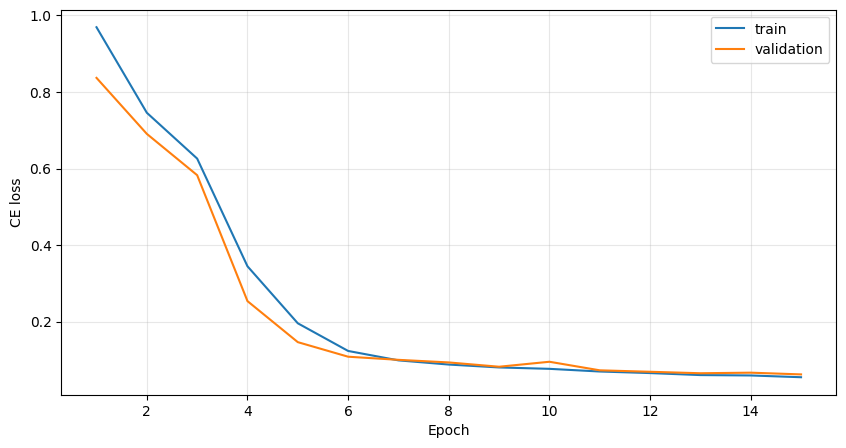

In [26]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, history["train_loss"], label="train")
ax.plot(epochs, history["val_loss"], label="validation")

ax.set_xlabel("Epoch")
ax.set_ylabel("CE loss")

ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

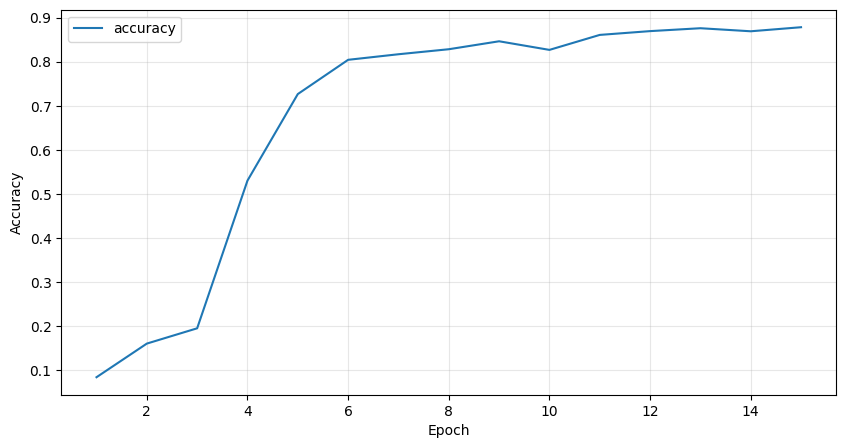

In [27]:
epochs = np.arange(1, len(history["val_acc"]) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, history["val_acc"], label="accuracy")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

In [48]:
!cugpt train --epochs 15 --batch-size 64 --checkpoint best_model.safetensors

train_size=45683 val_size=11421 sequence_length=21
Saved best checkpoint: best_model.safetensors (val_acc=0.0951756)
Epoch 1/15 | steps=714 | train_loss=0.961639 | val_loss=0.818986 | val_acc=0.0951756
Saved best checkpoint: best_model.safetensors (val_acc=0.180457)
Epoch 2/15 | steps=714 | train_loss=0.727835 | val_loss=0.634766 | val_acc=0.180457
Saved best checkpoint: best_model.safetensors (val_acc=0.474039)
Epoch 3/15 | steps=714 | train_loss=0.392141 | val_loss=0.280621 | val_acc=0.474039
Saved best checkpoint: best_model.safetensors (val_acc=0.592593)
Epoch 4/15 | steps=714 | train_loss=0.241687 | val_loss=0.213793 | val_acc=0.592593
Saved best checkpoint: best_model.safetensors (val_acc=0.694072)
Epoch 5/15 | steps=714 | train_loss=0.173364 | val_loss=0.159472 | val_acc=0.694072
Saved best checkpoint: best_model.safetensors (val_acc=0.761317)
Epoch 6/15 | steps=714 | train_loss=0.137508 | val_loss=0.133802 | val_acc=0.761317
Saved best checkpoint: best_model.safetensors (val_ac

In [49]:
import csv

with open("history.csv", newline="", encoding="utf-8") as f:
    history = {
        "step": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
    }

    for row in csv.DictReader(f):
        history["step"].append(int(row["step"]))
        history["train_loss"].append(float(row["train_loss"]))
        history["val_loss"].append(float(row["val_loss"]))
        history["val_acc"].append(float(row["val_acc"]))

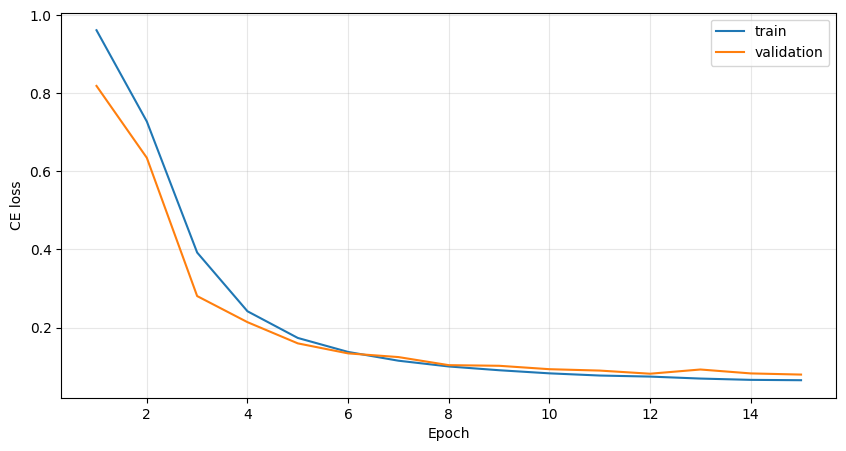

In [50]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, history["train_loss"], label="train")
ax.plot(epochs, history["val_loss"], label="validation")

ax.set_xlabel("Epoch")
ax.set_ylabel("CE loss")

ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

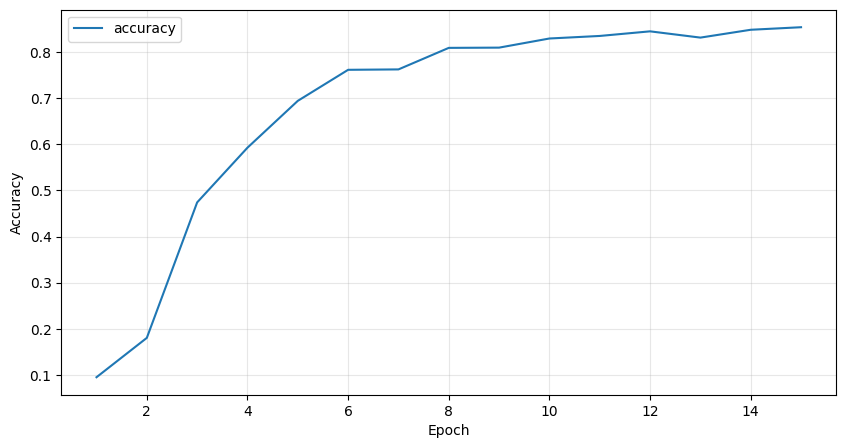

In [51]:
epochs = np.arange(1, len(history["val_acc"]) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, history["val_acc"], label="accuracy")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

In [43]:
load_model(model, "best_model.safetensors")

In [44]:
def generate(model: GPT, text: str, max_new_tokens=50):
    prompt = "<start> " + text.strip()
    end = math_data.token_to_id["<end>"]

    tokens = math_data.encode(prompt)
    tokens = xp.array(tokens, dtype=int)[None, :]

    for _ in range(max_new_tokens):
        mask = causal_mask(tokens.shape[1])

        logits = model(tokens, mask=mask)

        next_token = int(xp.argmax(logits[0, -1]))
        tokens = xp.concatenate(
            [tokens, xp.array([[next_token]], dtype=int)],
            axis=1,
        )

        if next_token == end:
            break

    return math_data.decode(tokens[0])

In [45]:
test_examples = [
    "<сотни> четыре <десятки> восемь <единицы> три плюс <десятки> два равно",
    "<сотни> семь <десятки> ноль <единицы> один минус <сотни> три равно",
    "<десятки> шесть умножить на <единицы> семь равно",
    "<сотни> восемь <десятки> четыре делить на <десятки> один <единицы> два равно",
]

In [46]:
for example in test_examples:
    print("input:", example)
    print("prediction:", generate(model, example))
    print()

input: <сотни> четыре <десятки> восемь <единицы> три плюс <десятки> два равно
prediction: <start> <сотни> четыре <десятки> восемь <единицы> три плюс <десятки> два равно <сотни> пять <десятки> ноль <единицы> три <end>

input: <сотни> семь <десятки> ноль <единицы> один минус <сотни> три равно
prediction: <start> <сотни> семь <десятки> ноль <единицы> один минус <сотни> три равно <сотни> четыре <десятки> ноль <единицы> один <end>

input: <десятки> шесть умножить на <единицы> семь равно
prediction: <start> <десятки> шесть умножить на <единицы> семь равно <сотни> четыре <десятки> два <end>

input: <сотни> восемь <десятки> четыре делить на <десятки> один <единицы> два равно
prediction: <start> <сотни> восемь <десятки> четыре делить на <десятки> один <единицы> два равно <десятки> семь <end>



In [47]:
for example in test_examples:
    !cugpt inference --checkpoint best_model.safetensors --text "{example}"
    print()

input: <сотни> четыре <десятки> восемь <единицы> три плюс <десятки> два равно
prediction: <start> <сотни> четыре <десятки> восемь <единицы> три плюс <десятки> два равно <сотни> пять <десятки> ноль <единицы> три <end>

input: <сотни> семь <десятки> ноль <единицы> один минус <сотни> три равно
prediction: <start> <сотни> семь <десятки> ноль <единицы> один минус <сотни> три равно <сотни> четыре <десятки> ноль <единицы> один <end>

input: <десятки> шесть умножить на <единицы> семь равно
prediction: <start> <десятки> шесть умножить на <единицы> семь равно <сотни> четыре <десятки> два <end>

input: <сотни> восемь <десятки> четыре делить на <десятки> один <единицы> два равно
prediction: <start> <сотни> восемь <десятки> четыре делить на <десятки> один <единицы> два равно <десятки> семь <end>

